In [47]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature
from cartopy.io import shapereader as shpreader
from shapely.geometry import Point, LineString, Polygon
from pysheds.grid import Grid
from rasterio.warp import Resampling
import numpy as np
import os
import glob

In [71]:
east_dem_path = "/scratch/dlhogan/ess-project-data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif"
tuol_dem_path = "/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif"

east_basin_shp = "/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp"
tuol_basin_shp = "/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment/Tuolumne_River_lumped_HRUs_GRUs.shp"

east_flow_shp = "/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_network/East_River_lumped_riverNetwork_lumped.shp"
tuol_flow_shp = "/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_network/Tuolumne_River_riverNetwork_delineate.shp"

crb_outline_path = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/01a_data_access/geodata/CRB_HydroBounds.json"
ucrb_outline_path = "/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/01a_data_access/geodata/Upper_Colorado_River_Basin_Boundary.json"


def centroid_lonlat(gdf):
    gdf_ll = gdf.to_crs("EPSG:4326")
    centroid = gdf_ll.geometry.union_all().centroid
    return centroid.x, centroid.y


def square_bounds(bounds, pad_m=2000):
    minx, miny, maxx, maxy = bounds
    width = maxx - minx
    height = maxy - miny
    size = max(width, height) + 2 * pad_m
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2
    half = size / 2
    return (cx - half, cy - half, cx + half, cy + half)


def hillshade(elevation, azimuth=315, altitude=45, cellsize=30):
    filled = np.where(np.isfinite(elevation), elevation, np.nan)
    dy, dx = np.gradient(filled, cellsize, cellsize)
    slope = np.pi / 2 - np.arctan(np.sqrt(dx * dx + dy * dy))
    aspect = np.arctan2(-dx, dy)
    az_rad = np.deg2rad(azimuth)
    alt_rad = np.deg2rad(altitude)
    shaded = (
        np.sin(alt_rad) * np.sin(slope)
        + np.cos(alt_rad) * np.cos(slope) * np.cos(az_rad - aspect)
    )
    return np.clip(shaded, 0, 1)


def elevation_bins(dem, step=200, max_ticks=12):
    vmin = float(np.nanmin(dem))
    vmax = float(np.nanmax(dem))
    start = np.floor(vmin / step) * step
    end = np.ceil(vmax / step) * step
    bounds = np.arange(start, end + step, step)
    ticks = bounds if len(bounds) <= max_ticks else bounds[::2]
    return bounds, ticks


def _read_network(path, target_crs):
    gdf = gpd.read_file(path)
    if target_crs:
        gdf = gdf.to_crs(target_crs)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf.explode(index_parts=False)
    return gdf


def _line_mask(gdf):
    return gdf.geometry.geom_type.isin(["LineString", "MultiLineString"])


def load_river_network(flow_shp, target_crs):
    flow_path = Path(flow_shp)
    candidates = [flow_path]
    candidates += sorted(flow_path.parent.glob("*riverNetwork_delineate*.shp"))
    candidates += sorted(flow_path.parent.glob("*riverNetwork_subset*.shp"))
    candidates += sorted(flow_path.parent.glob("*riverNetwork*.shp"))
    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        try:
            gdf = _read_network(candidate, target_crs)
        except Exception:
            continue
        line_mask = _line_mask(gdf)
        if line_mask.any():
            return gdf.loc[line_mask].copy()
    gdf = _read_network(flow_path, target_crs)
    line_mask = _line_mask(gdf)
    if line_mask.any():
        return gdf.loc[line_mask].copy()
    return gdf


def _finite_coords(coords):
    clean = []
    for x, y in coords:
        if np.isfinite(x) and np.isfinite(y):
            clean.append((float(x), float(y)))
    return clean


def build_pysheds_network(dem_path, basin_shp, target_crs=None, acc_threshold=50):
    acc_threshold = int(acc_threshold)
    grid = Grid.from_raster(str(dem_path))
    dem = grid.read_raster(str(dem_path))
    pit_filled = grid.fill_pits(dem)
    flooded = grid.fill_depressions(pit_filled)
    inflated = grid.resolve_flats(flooded)
    dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    fdir = grid.flowdir(inflated, dirmap=dirmap)
    acc = grid.accumulation(fdir, dirmap=dirmap)
    branches = grid.extract_river_network(fdir, acc > acc_threshold, dirmap=dirmap)
    lines = []
    for feature in branches.get("features", []):
        geom = feature.get("geometry", {})
        gtype = geom.get("type")
        coords = geom.get("coordinates", [])
        if gtype == "LineString":
            clean = _finite_coords(coords)
            if len(clean) > 1:
                lines.append(LineString(clean))
        elif gtype == "MultiLineString":
            for part in coords:
                clean = _finite_coords(part)
                if len(clean) > 1:
                    lines.append(LineString(clean))
    rivers = gpd.GeoDataFrame(geometry=lines, crs=grid.crs)
    if rivers.empty:
        return rivers
    if target_crs:
        rivers = rivers.to_crs(target_crs)
    basin = gpd.read_file(basin_shp)
    if target_crs:
        basin = basin.to_crs(target_crs)
    else:
        basin = basin.to_crs(rivers.crs)
    rivers = rivers.clip(basin)
    return rivers


def load_basin_layers(dem_path, basin_shp, flow_shp, pad_m=2000, target_crs=None, use_pysheds=True, acc_threshold=500):
    dem = rxr.open_rasterio(dem_path, masked=True).squeeze()
    if target_crs:
        dem = dem.rio.reproject(target_crs, resampling=Resampling.bilinear)
    dem_crs = dem.rio.crs
    basin = gpd.read_file(basin_shp).to_crs(dem_crs)
    if use_pysheds:
        try:
            flow = build_pysheds_network(dem_path, basin_shp, target_crs=dem_crs, acc_threshold=acc_threshold)
        except Exception:
            flow = load_river_network(flow_shp, dem_crs)
    else:
        flow = load_river_network(flow_shp, dem_crs)
    if flow is None or flow.empty:
        flow = load_river_network(flow_shp, dem_crs)
    bounds = square_bounds(basin.total_bounds, pad_m=pad_m)
    dem = dem.rio.clip_box(*bounds)
    minx, miny, maxx, maxy = dem.rio.bounds()
    extent = (minx, maxx, miny, maxy)
    res = float(abs(dem.rio.resolution()[0]))
    arr = dem.values
    if isinstance(arr, np.ma.MaskedArray):
        arr = arr.filled(np.nan)
    arr = arr.astype("float32")
    return arr, extent, basin, flow, res



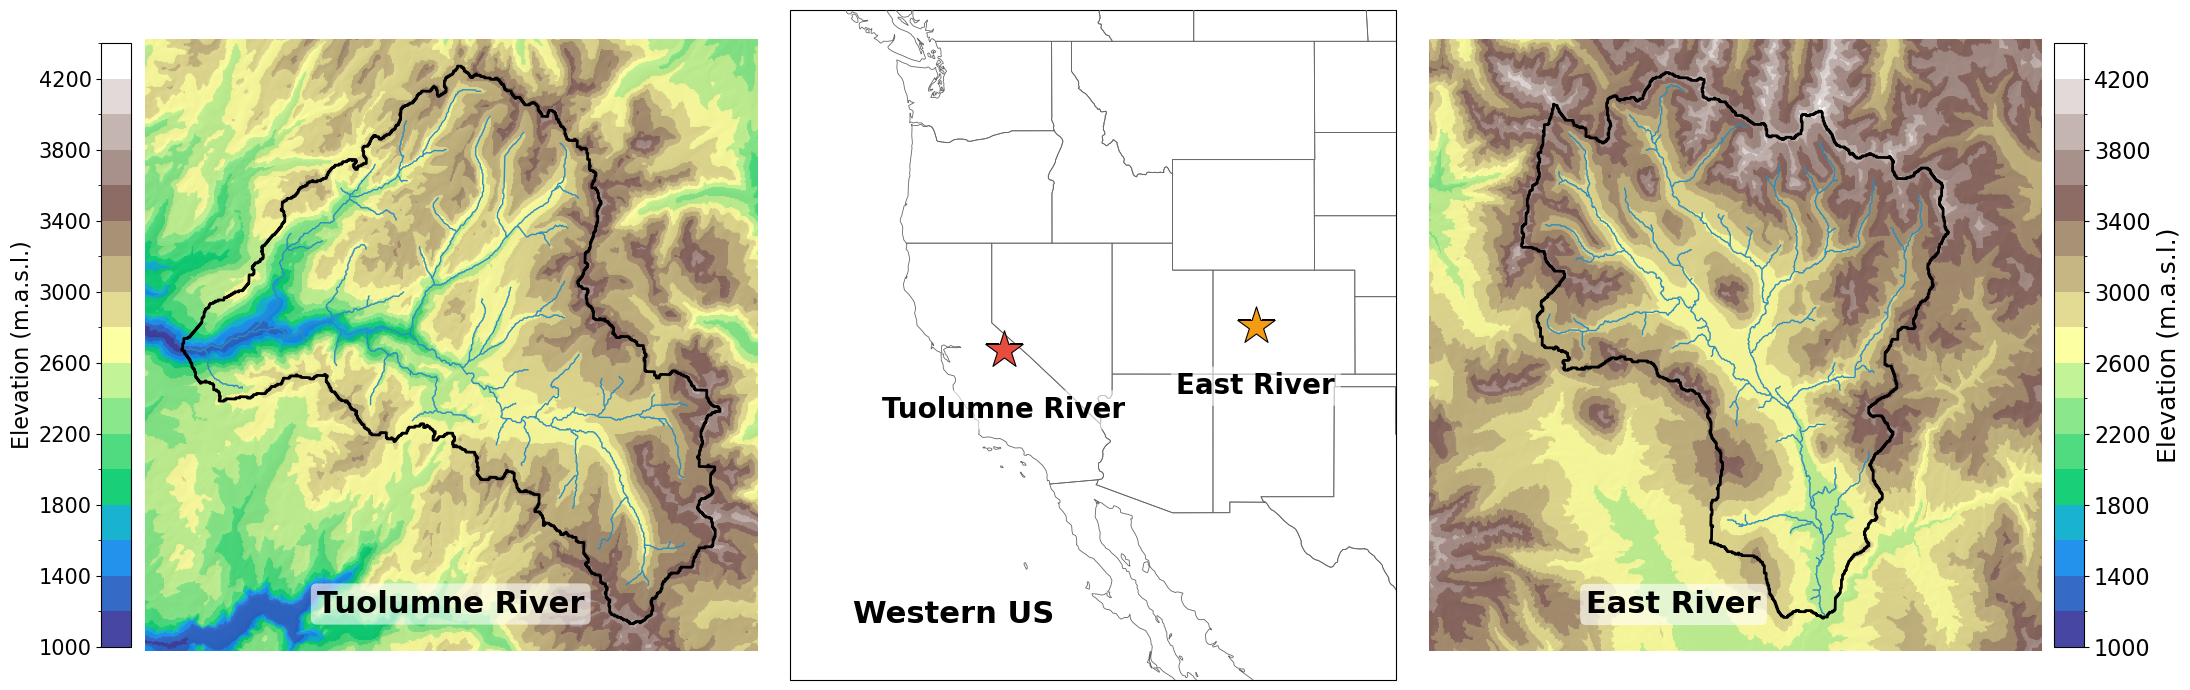

In [97]:
basin_east = gpd.read_file(east_basin_shp)
basin_tuol = gpd.read_file(tuol_basin_shp)
co_basin = gpd.read_file(crb_outline_path)
ucrb_outline = gpd.read_file(ucrb_outline_path)

tiler = cimgt.OSM()

fig = plt.figure(figsize=(22, 7))
ax_b = fig.add_subplot(1, 3, 1)                        # Tuolumne DEM — position A (left)
ax_a = fig.add_subplot(1, 3, 2, projection=tiler.crs)  # Overview map — position B (center)
ax_c = fig.add_subplot(1, 3, 3)                        # East River DEM — position C (right)

# ── Panel A: Tuolumne River DEM ───────────────────────────────────────────────

dem_t, extent_t, basin_t, flow_t, res_t = load_basin_layers(
    tuol_dem_path, tuol_basin_shp, tuol_flow_shp, pad_m=2000, target_crs="EPSG:32611"
)
shade_t = hillshade(dem_t, cellsize=res_t)
ax_b.imshow(shade_t, cmap="Greys", extent=extent_t, origin="upper", alpha=0.55)

# Fix colorbar range 1000–4400 m
clim_min, clim_max, clim_step = 1000, 4400, 200
bounds_t = np.arange(clim_min, clim_max + clim_step, clim_step)
ticks_t  = bounds_t[::2]
norm_t   = colors.BoundaryNorm(bounds_t, plt.get_cmap("terrain").N)
im_t = ax_b.imshow(dem_t, cmap="terrain", norm=norm_t, extent=extent_t, origin="upper", alpha=0.9)
im_t.set_clim(clim_min, clim_max)

basin_t.boundary.plot(ax=ax_b, edgecolor="black", linewidth=2, zorder=100)
flow_t.plot(ax=ax_b, color="#2b8cbe", linewidth=1.0)
ax_b.set_xlim(extent_t[0], extent_t[1])
ax_b.set_ylim(extent_t[2], extent_t[3])
ax_b.set_aspect("equal")
ax_b.axis("off")

# Colorbar on the LEFT side of panel A
cb_t = fig.colorbar(im_t, ax=ax_b, ticks=ticks_t, fraction=0.046, pad=0.02, location="left")
cb_t.set_label("Elevation (m.a.s.l.)", fontsize=16)
cb_t.ax.tick_params(labelsize=15)

# ax_b.text(
#     0.03, 0.98, "A",
#     transform=ax_b.transAxes, ha="left", va="top", fontsize=20, fontweight="bold",
#     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="square,pad=0.2"),
# )
ax_b.text(
    0.5, 0.1, "Tuolumne River",
    transform=ax_b.transAxes, ha="center", va="top", fontsize=22, fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"),
)

# ── Panel B: Overview map ─────────────────────────────────────────────────────

ax_a.set_extent([-130, -100, 24, 50], crs=ccrs.PlateCarree())
ax_a.add_feature(cfeature.STATES.with_scale("50m"), edgecolor="#666666", linewidth=0.6, zorder=3, facecolor="none")

countries_path = shpreader.natural_earth(resolution="50m", category="cultural", name="admin_0_countries")
mexico_geom = [
    record.geometry
    for record in shpreader.Reader(countries_path).records()
    if record.attributes.get("ADMIN") == "Mexico"
]
ax_a.add_geometries(
    mexico_geom,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="#666666",
    linewidth=0.6,
    zorder=3,
)

for gdf, edge in [(basin_east, "#f39c12"), (basin_tuol, "#e74c3c")]:
    gdf_ll = gdf.to_crs("EPSG:4326")
    ax_a.add_geometries(
        gdf_ll.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor=edge,
        linewidth=1.5,
        zorder=4,
    )

for name, gdf, color in [
    ("East River", basin_east, "#f39c12"),
    ("Tuolumne River", basin_tuol, "#e74c3c"),
]:
    lon, lat = centroid_lonlat(gdf)
    ax_a.scatter(
        lon, lat,
        transform=ccrs.PlateCarree(),
        marker="*", s=800, color=color, edgecolor="k", linewidth=0.8, zorder=6,
    )
    ax_a.text(
        lon, lat - 1.8, name,
        transform=ccrs.PlateCarree(),
        fontsize=20, fontweight="bold", color="black",
        ha="center", va="top", zorder=6,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"),
    )

ax_a.text(
    0.27, 0.12, "Western US",
    transform=ax_a.transAxes, ha="center", va="top", fontsize=22, fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"),
)
# ax_a.text(
#     0.03, 0.98, "B",
#     transform=ax_a.transAxes, ha="left", va="top", fontsize=22, fontweight="bold",
#     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="square,pad=0.2"),
# )

# ── Panel C: East River DEM ───────────────────────────────────────────────────

dem_e, extent_e, basin_e, flow_e, res_e = load_basin_layers(
    east_dem_path, east_basin_shp, east_flow_shp, pad_m=2500, target_crs="EPSG:32613", use_pysheds=True, acc_threshold=500
)
shade_e = hillshade(dem_e, cellsize=res_e)
ax_c.imshow(shade_e, cmap="Greys", extent=extent_e, origin="upper", alpha=0.55)

bounds_e = np.arange(clim_min, clim_max + clim_step, clim_step)
ticks_e  = bounds_e[::2]
norm_e   = colors.BoundaryNorm(bounds_e, plt.get_cmap("terrain").N)
im_e = ax_c.imshow(dem_e, cmap="terrain", norm=norm_e, extent=extent_e, origin="upper", alpha=0.9)
im_e.set_clim(clim_min, clim_max)

basin_e.boundary.plot(ax=ax_c, edgecolor="black", linewidth=2, zorder=100)
flow_e.plot(ax=ax_c, color="#2b8cbe", linewidth=1.0)
ax_c.set_xlim(extent_e[0], extent_e[1])
ax_c.set_ylim(extent_e[2], extent_e[3])
ax_c.set_aspect("equal")
ax_c.axis("off")
cb_e = fig.colorbar(im_e, ax=ax_c, ticks=ticks_e, fraction=0.046, pad=0.02)
cb_e.set_label("Elevation (m.a.s.l.)", fontsize=18)
cb_e.ax.tick_params(labelsize=16)

# ax_c.text(
#     0.03, 0.98, "C",
#     transform=ax_c.transAxes, ha="left", va="top", fontsize=20, fontweight="bold",
#     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="square,pad=0.2"),
# )
ax_c.text(
    0.4, 0.1, "East River",
    transform=ax_c.transAxes, ha="center", va="top", fontsize=22, fontweight="bold",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2"),
)

plt.tight_layout()
plt.show()
